In [1]:
from itertools import cycle

import numpy as np
import torch
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

_MODEL_CACHE = {}


def _load(model_name):
    from transformers import AutoTokenizer, AutoModelForCausalLM
    if model_name not in _MODEL_CACHE:
        tok = AutoTokenizer.from_pretrained(model_name)
        mdl = AutoModelForCausalLM.from_pretrained(model_name)
        _MODEL_CACHE[model_name] = (tok, mdl)
    return _MODEL_CACHE[model_name]


def _single_token_id(tokenizer, word, leading_space=True):
    text = (" " + word) if leading_space else word
    ids = tokenizer.encode(text)
    if len(ids) != 1:
        toks = tokenizer.convert_ids_to_tokens(ids)
        print(f"warning: {word!r} -> {len(ids)} tokens {toks}, using first")
    return ids[0]


def word_probability_heatmap(model_name, phrase, target_word_1, target_word_2,
                             changed_index, word, n=26, leading_space=True,
                             log=False, batch_size=32):
    """Heatmap of P(word) as the next token, over the simplex

        e = (1 - alpha - beta) * original + alpha * v1 + beta * v2

    Reads the word's probability out of the full softmax, so cells where it falls
    outside the top-5 still get a real value. Cells with alpha + beta > 1 are masked.
    """
    tokenizer, model = _load(model_name)
    embedding_layer = model.get_input_embeddings()

    def word_embedding(w):
        return embedding_layer.weight[_single_token_id(tokenizer, w, leading_space)]

    word_id = _single_token_id(tokenizer, word, leading_space)
    print(f"tracking {word!r} -> id {word_id} "
          f"({tokenizer.convert_ids_to_tokens([word_id])[0]!r})")

    inputs = tokenizer(phrase, return_tensors="pt")
    attn = inputs["attention_mask"]
    base_embeds = embedding_layer(inputs["input_ids"]).detach()
    original_vec = base_embeds[0, changed_index, :].clone()
    v1 = word_embedding(target_word_1)
    v2 = word_embedding(target_word_2)
    morph_word = tokenizer.decode([int(inputs["input_ids"][0][changed_index])]).strip()

    A = np.linspace(0, 1, n)
    B = np.linspace(0, 1, n)
    cells = [(i, j) for i in range(n) for j in range(n) if A[i] + B[j] <= 1 + 1e-9]

    P = np.full((n, n), np.nan)
    for s in range(0, len(cells), batch_size):
        chunk = cells[s:s + batch_size]
        embeds = base_embeds.repeat(len(chunk), 1, 1)
        for k, (i, j) in enumerate(chunk):
            a, b = float(A[i]), float(B[j])
            embeds[k, changed_index, :] = (1 - a - b) * original_vec + a * v1 + b * v2
        with torch.no_grad():
            logits = model(inputs_embeds=embeds,
                           attention_mask=attn.repeat(len(chunk), 1)).logits
        probs = torch.softmax(logits[:, -1, :], dim=-1)[:, word_id]
        for k, (i, j) in enumerate(chunk):
            P[i, j] = probs[k].item()

    Pm = np.ma.masked_invalid(P)
    lo, hi = float(Pm.min()), float(Pm.max())
    i_hi, j_hi = np.unravel_index(np.argmax(np.nan_to_num(P, nan=-1)), P.shape)
    print(f"P({word!r}) ranges {lo:.4g} -> {hi:.4g}")
    print(f"  max at alpha={A[i_hi]:.2f}, beta={B[j_hi]:.2f}")
    print(f"  at the three corners: original {P[0, 0]:.4g}, "
          f"{target_word_1} {P[n - 1, 0]:.4g}, {target_word_2} {P[0, n - 1]:.4g}")

    norm = LogNorm(vmin=max(lo, 1e-8), vmax=hi) if log else None
    cmap = plt.get_cmap("magma").copy()
    cmap.set_bad(color="white")

    fig, ax = plt.subplots(figsize=(8, 7))
    im = ax.imshow(Pm, origin="lower", extent=[0, 1, 0, 1], cmap=cmap,
                   norm=norm, aspect="auto", interpolation="nearest")
    ax.plot(B[j_hi], A[i_hi], marker="x", color="white", markersize=10, markeredgewidth=2)
    ax.plot([0, 1], [1, 0], color="gray", linewidth=0.8)

    ax.set_xlabel(f"beta (0 = {morph_word!r}, 1 = {target_word_2!r})")
    ax.set_ylabel(f"alpha (0 = {morph_word!r}, 1 = {target_word_1!r})")
    ax.set_title(f"P({word!r}) as the next token" + ("  [log scale]" if log else ""))
    fig.colorbar(im, ax=ax, label="probability")
    plt.tight_layout()
    plt.show()

    return P


def word_probability_heatmap_from_grid(top_5_at_each_alpha, tokenizer, word,
                                       leading_space=True, log=False):
    """Same heatmap read from a stored top-5 grid. Cells where the word is outside
    the top 5 are censored to 0 — the true probability there is unknown but smaller
    than the fifth-place token."""
    word_id = _single_token_id(tokenizer, word, leading_space)
    n = len(top_5_at_each_alpha)
    A = B = np.linspace(0, 1, n)

    P = np.full((n, n), np.nan)
    censored = 0
    for i in top_5_at_each_alpha:
        for j in top_5_at_each_alpha[i]:
            if A[i] + B[j] > 1 + 1e-9:
                continue
            t5 = top_5_at_each_alpha[i][j]
            hit = [p.item() for p, idx in zip(t5.values, t5.indices) if idx.item() == word_id]
            P[i, j] = hit[0] if hit else 0.0
            censored += not hit

    total = int(np.sum(~np.isnan(P)))
    print(f"{censored}/{total} cells censored to 0 ({word!r} outside top-5 there)")

    Pm = np.ma.masked_invalid(P)
    norm = LogNorm(vmin=max(float(Pm[Pm > 0].min()), 1e-8), vmax=float(Pm.max())) if log else None
    cmap = plt.get_cmap("magma").copy()
    cmap.set_bad(color="white")

    fig, ax = plt.subplots(figsize=(8, 7))
    im = ax.imshow(Pm, origin="lower", extent=[0, 1, 0, 1], cmap=cmap,
                   norm=norm, aspect="auto", interpolation="nearest")
    ax.plot([0, 1], [1, 0], color="gray", linewidth=0.8)
    ax.set_xlabel("beta")
    ax.set_ylabel("alpha")
    ax.set_title(f"P({word!r}) from stored top-5 (censored)")
    fig.colorbar(im, ax=ax, label="probability")
    plt.tight_layout()
    plt.show()

    return P

/Users/dariushghassemieh/llms/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 148/148 [00:00<00:00, 9075.26it/s]


tracking 'difficult' -> id 2408 ('Ġdifficult')
P('difficult') ranges 0.007157 -> 0.0732
  max at alpha=0.32, beta=0.56
  at the three corners: original 0.007157, hate 0.04395, question 0.06733


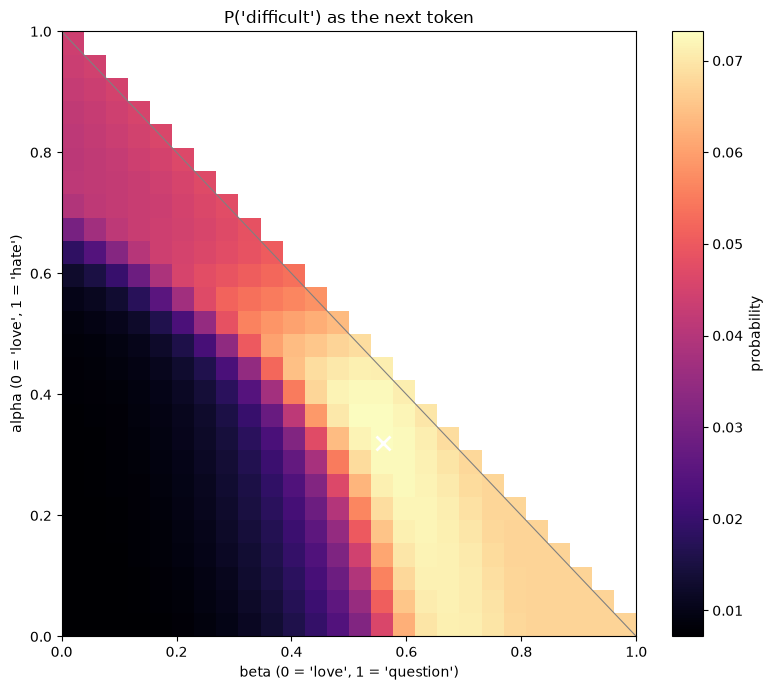

array([[0.0071572 , 0.00716209, 0.00721014, 0.00733475, 0.00761774,
        0.00812673, 0.00887448, 0.0099469 , 0.01145126, 0.01346709,
        0.01605872, 0.01938239, 0.02400913, 0.03180416, 0.04594983,
        0.06211872, 0.06973838, 0.07130417, 0.07093528, 0.06973357,
        0.06799959, 0.06743836, 0.06739476, 0.0673304 , 0.06730128,
        0.06733249],
       [0.00716919, 0.00718564, 0.00725306, 0.00742605, 0.00779741,
        0.0083918 , 0.00925143, 0.01047768, 0.01215973, 0.01435711,
        0.01714995, 0.02078123, 0.02606916, 0.0353335 , 0.05096874,
        0.06534253, 0.07074104, 0.07150812, 0.07086933, 0.06944197,
        0.0677471 , 0.06741872, 0.06738021, 0.06732495, 0.06730024,
               nan],
       [0.00718812, 0.00721639, 0.00731032, 0.00754462, 0.00799662,
        0.00867371, 0.00965085, 0.01102527, 0.01286619, 0.01523021,
        0.0182336 , 0.02224769, 0.02841824, 0.03945829, 0.05600946,
        0.06791907, 0.07142631, 0.07157205, 0.07068728, 0.06898535,
      

In [2]:
word_probability_heatmap(
    "gpt2", "I love school because it's very", "hate", "question",
    changed_index=1, word="difficult",
)